In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torch.optim.swa_utils import AveragedModel

## Configuration

In [11]:
# ── Chemins ─────────────────────────────────────────────────────────────────
CSV_PATH = "../data/dataset_selection_sans_leger.csv"

MODEL_PATHS = {
    "ConvNeXt-Small SWA": "convnext/convnext_swa_averaged.pth",
    "ConvNeXt-Tiny SWA":  "convnext/convnext_tiny_swa_averaged.pth",
    "DenseNet-169":       "densenet/densenet169_best.pth",
}

# Poids d'ensemble proportionnels aux accuracies individuelles
MODEL_WEIGHTS = {
    "ConvNeXt-Small SWA": 0.9494,
    "ConvNeXt-Tiny SWA":  0.9478,
    "DenseNet-169":       0.9399,
}

# ── TTA ─────────────────────────────────────────────────────────────────────
N_TTA = 5        # nombre de passes TTA (1 = pas de TTA, 5 = recommandé)
IMG_SIZE = 224
BATCH_SIZE = 32

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

for name, path in MODEL_PATHS.items():
    status = "✓" if os.path.exists(path) else "✗ MANQUANT"
    print(f"  {status}  {name} → {path}")

Device: cuda
  ✓  ConvNeXt-Small SWA → convnext/convnext_swa_averaged.pth
  ✓  ConvNeXt-Tiny SWA → convnext/convnext_tiny_swa_averaged.pth
  ✓  DenseNet-169 → densenet/densenet169_best.pth


## Données — même split que l'entraînement

In [12]:
df = pd.read_csv(CSV_PATH)
df = df.dropna(subset=["path", "label"]).reset_index(drop=True)
df = df[df["path"].apply(os.path.exists)].reset_index(drop=True)

le = LabelEncoder()
df["y"] = le.fit_transform(df["label"])
num_classes = len(le.classes_)
CLASS_NAMES = list(le.classes_)
print("Classes:", CLASS_NAMES)

# Split identique à tous les notebooks d'entraînement (random_state=42)
_, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["y"])
test_df, _ = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df["y"])
test_df = test_df.reset_index(drop=True)

print(f"Test set : {len(test_df)} images ({len(test_df)//num_classes} par classe)")

Classes: ['diabete', 'glaucome', 'mda', 'normaux']
Test set : 632 images (158 par classe)


## Utilitaires — crop, Dataset

In [13]:
def crop_black_border_pil(img: Image.Image, thr=10, pad=10):
    arr = np.array(img)
    mask = arr.mean(axis=2) > thr
    if not mask.any():
        return img
    ys, xs = np.where(mask)
    y0 = max(0, ys.min() - pad);  y1 = min(arr.shape[0] - 1, ys.max() + pad)
    x0 = max(0, xs.min() - pad);  x1 = min(arr.shape[1] - 1, xs.max() + pad)
    return img.crop((x0, y0, x1 + 1, y1 + 1))


class FundusDataset(Dataset):
    def __init__(self, dataframe, transform=None, do_crop=True):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.do_crop = do_crop

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["path"]).convert("RGB")
        if self.do_crop:
            img = crop_black_border_pil(img)
        if self.transform:
            img = self.transform(img)
        return img, int(row["y"])

## Transforms TTA

5 passes identiques aux augmentations d'entraînement : original, H-flip, V-flip, rotation +15°, ColorJitter (brightness/contrast/saturation).

In [14]:
_norm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

TTA_TRANSFORMS = [
    # 1 — original
    transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(), _norm,
    ]),
    # 2 — flip horizontal (p=0.5 à l'entraînement)
    transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(), _norm,
    ]),
    # 3 — flip vertical (p=0.2 à l'entraînement)
    transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomVerticalFlip(p=1.0),
        transforms.ToTensor(), _norm,
    ]),
    # 4 — ColorJitter identique à l'entraînement
    transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
        transforms.ToTensor(), _norm,
    ]),
    # 5 — rotation +15° (degrees=15 à l'entraînement)
    transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomRotation(degrees=(15, 15)),
        transforms.ToTensor(), _norm,
    ]),
]

print(f"{N_TTA} passes TTA configurées")

5 passes TTA configurées


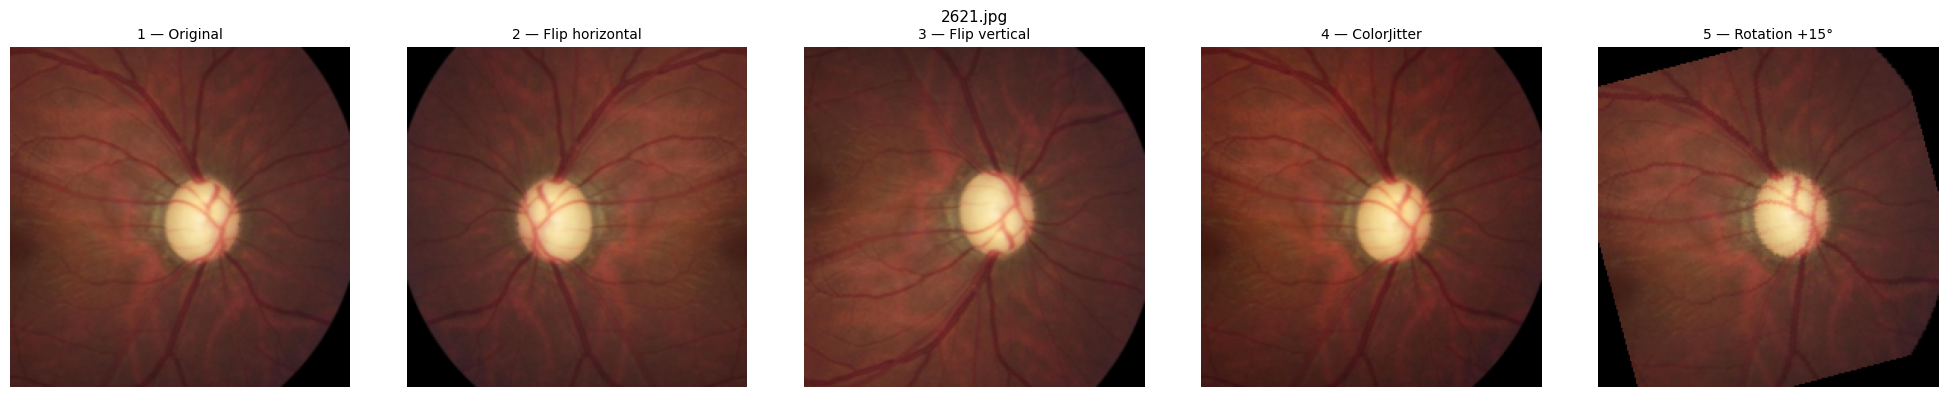

In [15]:
sample_path = test_df.iloc[0]["path"]
img_pil = crop_black_border_pil(Image.open(sample_path).convert("RGB"))

titles = ["1 — Original", "2 — Flip horizontal", "3 — Flip vertical",
          "4 — ColorJitter", "5 — Rotation +15°"]

to_pil = transforms.ToPILImage()
_denorm = transforms.Compose([
    transforms.Normalize(mean=[0,0,0], std=[1/0.229, 1/0.224, 1/0.225]),
    transforms.Normalize(mean=[-0.485, -0.456, -0.406], std=[1,1,1]),
])

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, tfm, title in zip(axes, TTA_TRANSFORMS, titles):
    ax.imshow(to_pil(_denorm(tfm(img_pil))))
    ax.set_title(title, fontsize=10)
    ax.axis("off")
plt.suptitle(os.path.basename(sample_path), fontsize=11)
plt.tight_layout()
plt.show()

## Fonction de prédiction TTA

In [16]:
def predict_tta(model, dataframe, device, n_tta=N_TTA):
    """Retourne (y_true, y_pred, proba_array) avec moyenne sur n_tta passes."""
    model.eval()
    all_probs = []

    for tfm in TTA_TRANSFORMS[:n_tta]:
        ds = FundusDataset(dataframe, transform=tfm, do_crop=True)
        loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=4, pin_memory=True)
        pass_probs = []
        with torch.no_grad():
            for x, _ in loader:
                probs = torch.softmax(model(x.to(device)), dim=1)
                pass_probs.append(probs.cpu().numpy())
        all_probs.append(np.concatenate(pass_probs, axis=0))

    proba = np.mean(all_probs, axis=0)  # moyenne des passes
    y_true = dataframe["y"].values
    y_pred = proba.argmax(axis=1)
    return y_true, y_pred, proba


def plot_cm(cm, class_names, title="Confusion Matrix"):
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, data, fmt, t in zip(axes, [cm, cm_norm], ["d", ".2f"],
                                 [title, title + " (normalisée)"]):
        im = ax.imshow(data, cmap="Blues")
        ax.set_xticks(range(len(class_names))); ax.set_xticklabels(class_names, rotation=45, ha="right")
        ax.set_yticks(range(len(class_names))); ax.set_yticklabels(class_names)
        ax.set_xlabel("Prédit"); ax.set_ylabel("Vrai"); ax.set_title(t)
        for i in range(len(class_names)):
            for j in range(len(class_names)):
                val = data[i, j]
                ax.text(j, i, f"{val:.2f}" if fmt == ".2f" else str(val),
                        ha="center", va="center",
                        color="white" if val > data.max() * 0.6 else "black")
    plt.tight_layout(); plt.show()

## Chargement des 3 modèles

In [17]:
# ── ConvNeXt-Small + SWA ────────────────────────────────────────────────────
_base_small = models.convnext_small(weights=None)
_base_small.classifier[2] = nn.Linear(_base_small.classifier[2].in_features, num_classes)
model_convnext_small = AveragedModel(_base_small)
model_convnext_small.load_state_dict(
    torch.load(MODEL_PATHS["ConvNeXt-Small SWA"], map_location=device, weights_only=True))
model_convnext_small = model_convnext_small.to(device).eval()
print("✓ ConvNeXt-Small SWA chargé")

# ── ConvNeXt-Tiny + SWA ─────────────────────────────────────────────────────
_base_tiny = models.convnext_tiny(weights=None)
_base_tiny.classifier[2] = nn.Linear(_base_tiny.classifier[2].in_features, num_classes)
model_convnext_tiny = AveragedModel(_base_tiny)
model_convnext_tiny.load_state_dict(
    torch.load(MODEL_PATHS["ConvNeXt-Tiny SWA"], map_location=device, weights_only=True))
model_convnext_tiny = model_convnext_tiny.to(device).eval()
print("✓ ConvNeXt-Tiny SWA chargé")

# ── DenseNet-169 ────────────────────────────────────────────────────────────
model_densenet = models.densenet169(weights=None)
model_densenet.classifier = nn.Linear(model_densenet.classifier.in_features, num_classes)
model_densenet.load_state_dict(
    torch.load(MODEL_PATHS["DenseNet-169"], map_location=device, weights_only=True))
model_densenet = model_densenet.to(device).eval()
print("✓ DenseNet-169 chargé")

✓ ConvNeXt-Small SWA chargé
✓ ConvNeXt-Tiny SWA chargé
✓ DenseNet-169 chargé


## Évaluation individuelle avec TTA


  ConvNeXt-Small SWA  (TTA x5)

Accuracy : 0.9652   |   AUC-ROC macro : 0.9930
              precision    recall  f1-score   support

     diabete     0.9684    0.9684    0.9684       158
    glaucome     0.9689    0.9873    0.9781       158
         mda     0.9576    1.0000    0.9783       158
     normaux     0.9662    0.9051    0.9346       158

    accuracy                         0.9652       632
   macro avg     0.9653    0.9652    0.9648       632
weighted avg     0.9653    0.9652    0.9648       632



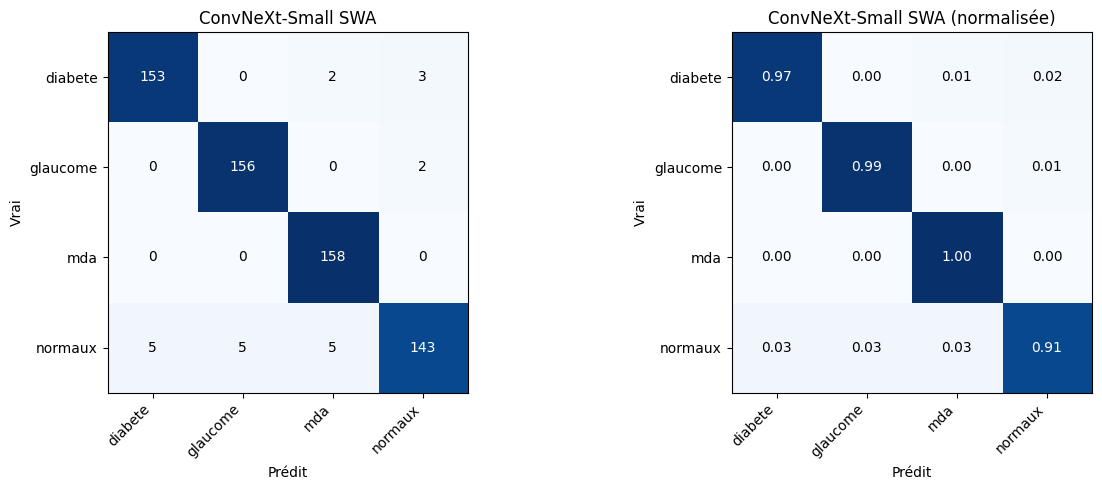


  ConvNeXt-Tiny SWA  (TTA x5)

Accuracy : 0.9826   |   AUC-ROC macro : 0.9968
              precision    recall  f1-score   support

     diabete     0.9873    0.9873    0.9873       158
    glaucome     0.9632    0.9937    0.9782       158
         mda     1.0000    1.0000    1.0000       158
     normaux     0.9804    0.9494    0.9646       158

    accuracy                         0.9826       632
   macro avg     0.9827    0.9826    0.9825       632
weighted avg     0.9827    0.9826    0.9825       632



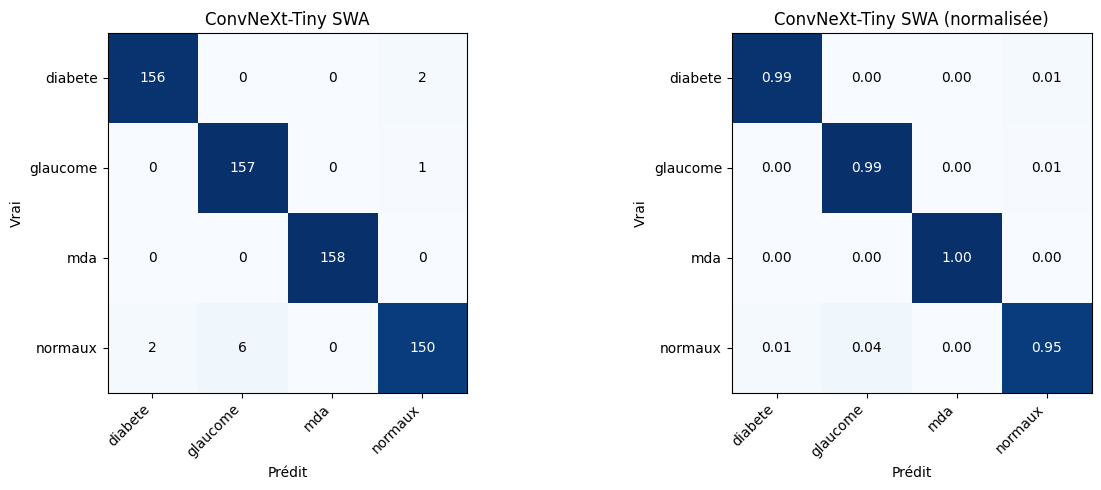


  DenseNet-169  (TTA x5)

Accuracy : 0.9794   |   AUC-ROC macro : 0.9971
              precision    recall  f1-score   support

     diabete     0.9936    0.9873    0.9905       158
    glaucome     0.9458    0.9937    0.9691       158
         mda     1.0000    1.0000    1.0000       158
     normaux     0.9801    0.9367    0.9579       158

    accuracy                         0.9794       632
   macro avg     0.9799    0.9794    0.9794       632
weighted avg     0.9799    0.9794    0.9794       632



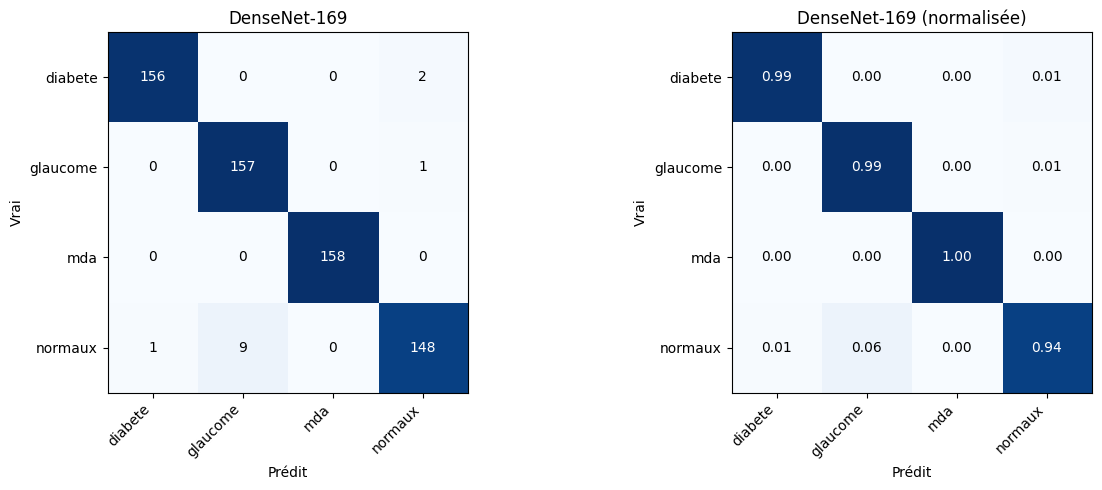

In [18]:
loaded_models = {
    "ConvNeXt-Small SWA": model_convnext_small,
    "ConvNeXt-Tiny SWA":  model_convnext_tiny,
    "DenseNet-169":       model_densenet,
}

results = {}  # stocke (y_true, y_pred, proba) pour l'ensemble

for name, model in loaded_models.items():
    print(f"\n{'='*60}")
    print(f"  {name}  (TTA x{N_TTA})")
    print(f"{'='*60}")

    y_true, y_pred, proba = predict_tta(model, test_df, device)
    results[name] = (y_true, y_pred, proba)

    acc = (y_true == y_pred).mean()
    auc = roc_auc_score(y_true, proba, multi_class="ovr", average="macro")
    print(f"\nAccuracy : {acc:.4f}   |   AUC-ROC macro : {auc:.4f}")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))
    plot_cm(confusion_matrix(y_true, y_pred), CLASS_NAMES, title=name)

## Ensemble pondéré (soft voting)

Poids proportionnels à l'accuracy individuelle de chaque modèle.

  ENSEMBLE (TTA x5)

Accuracy : 0.9842   |   AUC-ROC macro : 0.9992
              precision    recall  f1-score   support

     diabete     0.9937    0.9937    0.9937       158
    glaucome     0.9573    0.9937    0.9752       158
         mda     1.0000    1.0000    1.0000       158
     normaux     0.9868    0.9494    0.9677       158

    accuracy                         0.9842       632
   macro avg     0.9845    0.9842    0.9841       632
weighted avg     0.9845    0.9842    0.9841       632



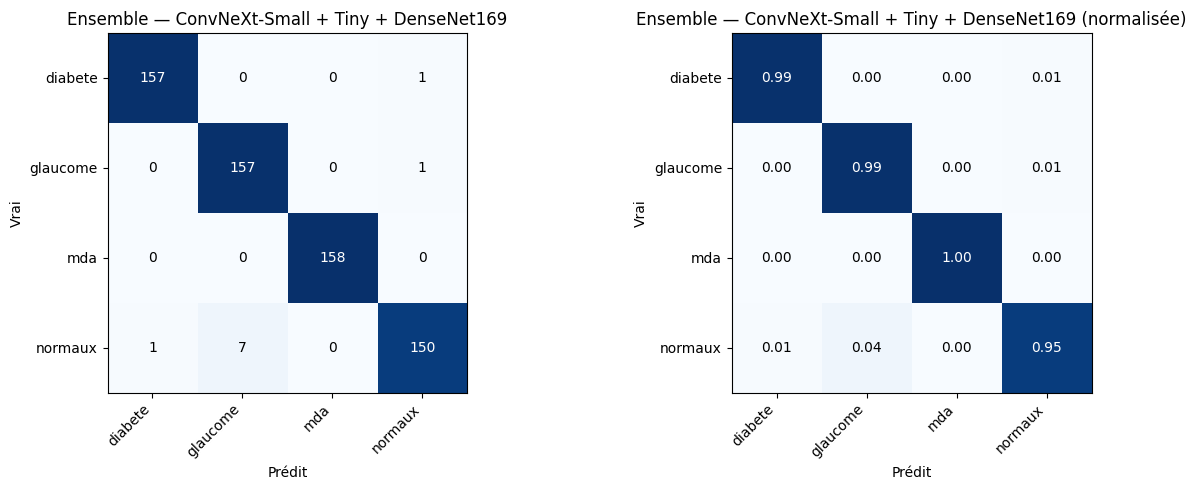

In [19]:
total_weight = sum(MODEL_WEIGHTS[n] for n in loaded_models)
ensemble_proba = sum(
    (MODEL_WEIGHTS[name] / total_weight) * results[name][2]
    for name in loaded_models
)

y_true_ens = results["ConvNeXt-Small SWA"][0]  # identique pour tous
y_pred_ens = ensemble_proba.argmax(axis=1)

acc_ens = (y_true_ens == y_pred_ens).mean()
auc_ens = roc_auc_score(y_true_ens, ensemble_proba, multi_class="ovr", average="macro")

print(f"{'='*60}")
print(f"  ENSEMBLE (TTA x{N_TTA})")
print(f"{'='*60}")
print(f"\nAccuracy : {acc_ens:.4f}   |   AUC-ROC macro : {auc_ens:.4f}")
print(classification_report(y_true_ens, y_pred_ens, target_names=CLASS_NAMES, digits=4))
plot_cm(confusion_matrix(y_true_ens, y_pred_ens), CLASS_NAMES, title="Ensemble — ConvNeXt-Small + Tiny + DenseNet169")

## Récapitulatif

In [ ]:
print(f"{'Modèle':<30} {'Acc (sans TTA)':<18} {'Acc (TTA x'+str(N_TTA)+')':<18} {'AUC-ROC':<10}")
print("-" * 78)

ref_accs = {
    "ConvNeXt-Small SWA": 0.9494,
    "ConvNeXt-Tiny SWA":  0.9478,
    "DenseNet-169":       0.9399,
}

for name in loaded_models:
    yt, yp, proba = results[name]
    acc_tta = (yt == yp).mean()
    auc = roc_auc_score(yt, proba, multi_class="ovr", average="macro")
    delta = acc_tta - ref_accs[name]
    sign = "+" if delta >= 0 else ""
    print(f"{name:<30} {ref_accs[name]:<18.4f} {acc_tta:<18.4f} {auc:.4f}  ({sign}{delta:.4f})")

print("-" * 78)
best_ref = max(ref_accs.values())
delta_ens = acc_ens - best_ref
sign = "+" if delta_ens >= 0 else ""
print(f"{'ENSEMBLE':<30} {best_ref:<18.4f} {acc_ens:<18.4f} {auc_ens:.4f}  ({sign}{delta_ens:.4f})")

Modèle                         Acc (sans TTA)     Acc (TTA x5)       AUC-ROC   
------------------------------------------------------------------------------
ConvNeXt-Small SWA             0.9494             0.9652             0.9930  (+0.0158)
ConvNeXt-Tiny SWA              0.9478             0.9826             0.9968  (+0.0348)
DenseNet-169                   0.9163             0.9794             0.9971  (+0.0631)
------------------------------------------------------------------------------
ENSEMBLE                       0.9494             0.9842             0.9992  (+0.0348)
